#### Name: Solutions

# PHYS 230 Lab Assignment 8

### Wednesday, February 18: Chapter 5.1-5.3
- Evaluating integrals in python 
    - Trapezoidal Rule
    - Simpson's Rule

#### Start by importing any packages you need below (feel free to update as you go):

In [1]:
import numpy as np


## The overall goal of lab today 

Today we are going to evaluate the integral: 
$$\int_{1.1}^{10.1} \frac{\sin{x}}{\ln{x}} \,dx $$

### Step 1 (10 pts)

Write a user-defined function `f(x)` to evaluate the given **function** in the integral. Include comments in your code (and markdown cell, if necessary) explaining your process. 

In [2]:
# first define function to use in trapezoidal and simpson's rules
def f(x):
    return np.sin(x)/np.log(x)

### Applying Trapezoidal Rule (20 pts)


Write a code to do the following: 
- Create a user-defined function `trapezoidal_int(a,b,N,f)` to determine the integral using the trapezoidal rule using your function defined above 

    - here: a = the lower limit of the integrand, b = upper limit, N = number of steps, and f = the function from above 
- Do so using $N = 100$ steps
- Do so again by doubling the number of steps and seeing how much the result accuracy changes by. 
- Estimate the error on the result using the equation discussed in class. 

When your program is complete, add a markdown cell below it to explain your process and program. Don't forget to comment in your code

In [4]:
# Function to integrate using Trapezoidal Rule 
# create function to apply extended trapezoidal rule for integration 
def trapezoidal_int(a,b,N,f): 
    # a = lower limit of integration 
    # b = upper limit of integration 
    # N = number of steps 
    # func = function that you are integrating, should be a user-defined function 
    
    # calculate h - width of each step
    h = (b-a)/N

    #integrate using extended trapezoidal rule
    s = 0.5*f(a)+0.5*f(b)
    for k in range(1,N):
        s += f(a+k*h)
    I = h*s

    # return value of the integral 
    return(I)


In [5]:
# N = 100 steps 

# define steps and limits of integration
# start with 100 steps 
N = 100
a = 1.1
b = 10.1


# call function
I1 = trapezoidal_int(a,b,N,f)
print(I1)


2.9021883624907003


In [6]:
# double steps 
N = 200

# call function
I2 = trapezoidal_int(a,b,N,f)
print(I2)

2.8628779013854735


In [8]:
# estimate error 
# estimate error using trapezoidal rule error equation: 
delta_t = np.abs((I2-I1)/3)
print("the approximation error is I2 = ", delta_t)

# calculate % error out of curiosity
percent = delta_t/I2*100
print("which is a percent error of ", percent)

the approximation error is I2 =  0.013103487035075615
which is a percent error of  0.45770331416279597


### Applying Simpson's Rule (20 pts)

Write a code to do the following: 
- Create a user-defined function `simpsons_int(a,b,N,f)` to determine the integral using Simpson's rule using your function defined above 

    - here: a = the lower limit of the integrand, b = upper limit, N = number of steps, and f = the function from above 
- Do so using $N = 50$ steps [note this is half of the initial steps used in trapezoidal]
- Do so again by doubling the number of steps and seeing how much the result accuracy changes by. 
- Estimate the error on the result using the equation discussed in class. 

When your program is complete, add a markdown cell below it to explain your process and program. Don't forget to comment in your code. 

In [9]:
# Function to integrate using Simpsons Rule 
# create function to apply extended trapezoidal rule for integration 
def simpsons_int(a,b,N,f): 
    # a = lower limit of integration 
    # b = upper limit of integration 
    # N = number of steps 
    # func = function that you are integrating, should be a user-defined function 
    
    # calculate h - width of each step
    h = (b-a)/N

    # evaluate using simpson's rule
    s = f(a) + f(b)
    for k in range(1,N):
        if k%2 == 1: # checking for odd
            s+= 4*f(a+k*h)
        else:
            s += 2*f(a+k*h)
    I = h/3*s

    ### alternative 
    #s1 = 0.0
    #for k in range(1,N,2):
    #    s1 += f(a+k*h)
    #s2 = 0.0
    #for k in range(2,N,2):
    #    s2 += f(a+k*h)   
    #I = h/3*(f(a)+f(b)+4*s1+2*s2)
    #print(I)
    
    # return value of the integral 
    return(I)

In [10]:
#N = 50 steps 

# define steps and limits of integration
# start with 100 steps 
N = 50
a = 1.1
b = 10.1


# call function
I1_s = simpsons_int(a,b,N,f)
print(I1_s)

2.9012217056816034


In [11]:
# double steps 
N = 100

# call function
I2_s = simpsons_int(a,b,N,f)
print(I2_s)

2.856855482008929


In [14]:
# error 
# estimate error using simpson's rule error equation: 
delta_s = np.abs((I2_s-I1_s)/15)
print("the approximation error is I2 using Simpson's rule = ", delta_s)

# calculate % error out of curiosity
percent_s = delta_s/I2_s*100
print("which is a percent error of ", percent_s)

the approximation error is I2 using Simpson's rule =  0.0029577482448449525
which is a percent error of  0.10353160191236122


### Evaluating error and number of steps (20 pts)

In a markdown cell, discuss your results from the two different methods above. In particular, focus on the following: 
- Each method uses a different number of steps, which also means different amounts of time. How do their error estimates compare? 
- Comment on the estimated error for each compared to the direct computation of error (the difference between your value and the true value of 2.84895)
- Does the number of steps in each calculation seem appropriate? To determine this, think about what what accuracy is desired in this calculation and compare it with the measured errors. Let's say that we want to calculate the integrand to a target accuracy of 0.003
    - comment on the two different techniques with regard to this result
    - if either of the results don't meet the desired accuracy, determine how many steps are necessary to do so using the appropriate equation for doubling the number of steps (see section 5.3 in the book). For example, for Trapezoidal rule: 
    $$ I_i = \frac{1}{2}I_{i-1} + h_i\sum_{k=1 (k \text{ odd})}^{N_i-1} f(a+kh_i)$$


#### Answers: 
- how do error estimates compare: 
    - the error estimate for the trapezoidal approximation is significantly larger than the error estimate of the Simpson's approximation


- estimated error compared to direct computation of error 
    - (see below for calculation) The direct computation error and estimated error for trapezoidal seem to match, but the direct computation vs. estimated for Simpson's do not match. The estimated error is underestimated, showing potential issues with this method 
    - for trapezoidal: direct computation error = 0.013927901385473618, while estimated error = 0.013103487035075615
    - for Simpson's: direct computation error = 0.00790548200892971, while estimated error = 0.0029577482448448636
    
    
- do number of steps seem appropriate?
    - Since the desired error is 0.003, to achieve an approximation error of < 0.003, we need to use 500 steps compared to the 100 that was required for Simpson's 



In [15]:
# For Trapezoidal - calculate direct error 
trap_directerr = np.abs(2.84895-I2)
print(trap_directerr)

# define steps and limits of integration
# start with 100 steps 
N = 100
a = 1.1
b = 10.1
# calculate h - width of each step 
h = (b-a)/N
I1_t = trapezoidal_int(a,b,N,f)

# evaluate element outside of sum in trapezoidal rule equation 
err_t = 100
I2_t = I1_t
while err_t > 0.003:
    I1_t = I2_t
    N = 2*N
    h2 = (b-a)/N

    I2_t = 0.5*I1_t
    s2 = 0
    for k in range(1,N):
        if k%2==1:
            s2 += f(a+k*h2)

    I2_t += h2*s2
    print(I1_t, I2_t)
    err_t = 1/3*np.abs(I2_t - I1_t)
    print(N, "steps had an error of: ", err_t)
    
print("Required number of steps is: ", N)
print("Achieved error of ", err_t)



0.013927901385473618
2.9021883624907003 2.8628779013854766
200 steps had an error of:  0.013103487035074579
2.8628779013854766 2.8524803072663243
400 steps had an error of:  0.003465864706384103
2.8524803072663243 2.8498356757150973
800 steps had an error of:  0.0008815438504089871
Required number of steps is:  800
Achieved error of  0.0008815438504089871


### Integrating Data 

In GitHub, you will find a file called `forces.txt`, which contins two columns of numbers. The first column reprsents the distance $x$ in meters and the second is the force $F$ along the x-direction in Newtons on the particle. We want to determine the work done on the particle, by doing the following: 

- read in the data
- use the trapezoidal rule to calculate the approximate work done on the particle in the $x$-direction. 
- plot the original force vs. distance data 
- plot the total work as a function of distance on the same graph 

Remember that: 

$$ W = \int_a^b F(x) \,d x $$


The total work on the object is 1.2691430000000001 J


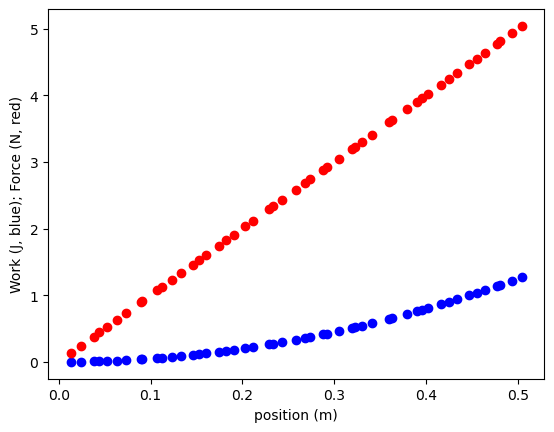

In [39]:
import matplotlib.pyplot as plt
## part a & b
# read in the data 
data = np.loadtxt("forces.txt",float)
x = data[:,0]
F = data[:,1]
N = len(x)

# no need to define a function of the function since rather simple
W = 0
W_arr = np.zeros(N,float)
# s[0] should be zero since starting at x = 0
for i in range(1,N):
    W += 0.5*(x[i]-x[i-1])*(F[i]+F[i-1])
    # for part b at the array 
    W_arr[i] = W_arr[i-1]+0.5*(x[i]-x[i-1])*(F[i]+F[i-1])

#print(s_arr)
print("The total work on the object is", W_arr[-1], "J")

plt.plot(x,W_arr, "bo")
plt.plot(x,F, "ro")
plt.xlabel("position (m)")
plt.ylabel("Work (J, blue); Force (N, red)")
plt.show()

#### How data `forces.txt` was produced

In [35]:
def w(x, k): 
    w = 0.5*k*x**2
    return(w)

def force(x, k): 
    force = k*x
    return force

import random 
import numpy as np

work_arr = np.ones([50,2],float)
k = 10

for i in range(len(work_arr[:,0])):
    work_arr[i,0] = "{:.3f}".format(random.random()+(i+1))
#print(work_arr)   

work_arr = work_arr/100
#print(work_arr)   


for i in range(len(work_arr[:,0])):
    work_arr[i,1] = "{:.3f}".format(force(work_arr[i,0],k))
print(work_arr)  

np.savetxt('forces.txt', work_arr, fmt='%.3f')


[[0.01272 0.127  ]
 [0.02414 0.241  ]
 [0.03814 0.381  ]
 [0.04435 0.443  ]
 [0.05303 0.53   ]
 [0.06323 0.632  ]
 [0.07327 0.733  ]
 [0.08956 0.896  ]
 [0.09138 0.914  ]
 [0.10748 1.075  ]
 [0.11234 1.123  ]
 [0.12311 1.231  ]
 [0.13316 1.332  ]
 [0.14608 1.461  ]
 [0.1529  1.529  ]
 [0.16024 1.602  ]
 [0.17376 1.738  ]
 [0.1822  1.822  ]
 [0.19069 1.907  ]
 [0.20343 2.034  ]
 [0.2112  2.112  ]
 [0.22932 2.293  ]
 [0.23336 2.334  ]
 [0.24298 2.43   ]
 [0.25769 2.577  ]
 [0.26845 2.684  ]
 [0.27377 2.738  ]
 [0.28831 2.883  ]
 [0.29192 2.919  ]
 [0.30471 3.047  ]
 [0.31908 3.191  ]
 [0.32265 3.226  ]
 [0.33024 3.302  ]
 [0.34089 3.409  ]
 [0.35972 3.597  ]
 [0.36286 3.629  ]
 [0.37878 3.788  ]
 [0.38956 3.896  ]
 [0.39552 3.955  ]
 [0.40159 4.016  ]
 [0.41615 4.162  ]
 [0.42461 4.246  ]
 [0.43352 4.335  ]
 [0.44674 4.467  ]
 [0.45496 4.55   ]
 [0.46357 4.636  ]
 [0.47656 4.766  ]
 [0.48096 4.81   ]
 [0.49401 4.94   ]
 [0.50406 5.041  ]]
